# Assistant


Azure OpenAI Assistants를 사용하면 사용자 지정 지침과 코드 인터프리터, 사용자 지정 함수와 같은 고급 도구를 통해 필요에 맞는 AI 어시스턴트를 만들 수 있습니다. 이 문서에서는 Assistants API를 시작하는 방법에 대한 심층적인 가이드를 제공합니다.


## API 버전: 2024-02-15-preview
사용 가능 여부 확인: 

https://learn.microsoft.com/en-us/azure/ai-services/openai/concepts/models#assistants-preview

## 어시스턴트 생성

In [1]:
import os
import json
from openai import AzureOpenAI
from azure.identity import DefaultAzureCredential, get_bearer_token_provider
from dotenv import load_dotenv

# Load the environment variables from the .env file
load_dotenv(override=True)

credential = DefaultAzureCredential()
token_provider = get_bearer_token_provider(credential, "https://cognitiveservices.azure.com/.default")
    
client = AzureOpenAI(
    azure_ad_token_provider=token_provider,
    api_version="2025-03-01-preview",
    azure_endpoint = os.getenv("AZURE_OPENAI_ENDPOINT"),
)

# Create an assistant
assistant = client.beta.assistants.create(
    name="Data Visualization",
    instructions=
    """
        당신은 데이터 기반으로 흥미로운 시각화를 만드는 유용한 AI 어시스턴트입니다.
        코드를 작성하고 테스트할 수 있는 샌드박스 환경에 접근할 수 있습니다.
        시각화 생성을 요청받으면 다음 단계를 따르세요:
        1. 코드를 작성하세요.
        2. 새로운 코드를 작성할 때마다 미리보기를 표시하여 작업 과정을 보여주세요.
        3. 코드를 실행하여 정상 동작하는지 확인하세요.
        4. 코드가 성공적으로 실행되면 시각화를 표시하세요.
        5. 코드 실행에 실패하면 오류 메시지를 표시하고, 코드를 수정하여 위 단계를 반복하세요.
    """,
    tools=[{"type": "code_interpreter"}],
    model = os.getenv("AZURE_OPENAI_DEPLOYMENT_NAME")
)

In [2]:
print(assistant.model_dump_json(indent=2))

{
  "id": "asst_LwX3Bv0D0ysiVWbcMZa2Dpbl",
  "created_at": 1772442784,
  "description": null,
  "instructions": "\n        당신은 데이터 기반으로 흥미로운 시각화를 만드는 유용한 AI 어시스턴트입니다.\n        코드를 작성하고 테스트할 수 있는 샌드박스 환경에 접근할 수 있습니다.\n        시각화 생성을 요청받으면 다음 단계를 따르세요:\n        1. 코드를 작성하세요.\n        2. 새로운 코드를 작성할 때마다 미리보기를 표시하여 작업 과정을 보여주세요.\n        3. 코드를 실행하여 정상 동작하는지 확인하세요.\n        4. 코드가 성공적으로 실행되면 시각화를 표시하세요.\n        5. 코드 실행에 실패하면 오류 메시지를 표시하고, 코드를 수정하여 위 단계를 반복하세요.\n    ",
  "metadata": {},
  "model": "gpt-4.1",
  "name": "Data Visualization",
  "object": "assistant",
  "tools": [
    {
      "type": "code_interpreter"
    }
  ],
  "response_format": "auto",
  "temperature": 1.0,
  "tool_resources": {
    "code_interpreter": {
      "file_ids": []
    },
    "file_search": null
  },
  "top_p": 1.0
}


## 스레드 생성

스레드는 어시스턴트와 사용자 간의 대화 세션입니다. 스레드는 메시지를 저장하며 모델의 컨텍스트에 맞게 내용을 자동으로 잘라냅니다.

In [3]:
# Create a thread
thread = client.beta.threads.create()
print(thread)

Thread(id='thread_5wbq3GVBMfOcipsqEEmNeIY0', created_at=1772442810, metadata={}, object='thread', tool_resources=ToolResources(code_interpreter=None, file_search=None))


In [4]:
# Add a user question to the thread
message = client.beta.threads.messages.create(
    thread_id=thread.id,
    role="user",
    content="사인파 시각화 만들기"
)

In [5]:
# list thread messages
thread_messages = client.beta.threads.messages.list(thread.id)
print(thread_messages.model_dump_json(indent=2))

{
  "data": [
    {
      "id": "msg_L4XYhlUxgsqzJuo1HT7NdlV4",
      "assistant_id": null,
      "attachments": [],
      "completed_at": null,
      "content": [
        {
          "text": {
            "annotations": [],
            "value": "사인파 시각화 만들기"
          },
          "type": "text"
        }
      ],
      "created_at": 1772442816,
      "incomplete_at": null,
      "incomplete_details": null,
      "metadata": {},
      "object": "thread.message",
      "role": "user",
      "run_id": null,
      "status": null,
      "thread_id": "thread_5wbq3GVBMfOcipsqEEmNeIY0"
    }
  ],
  "has_more": false,
  "object": "list",
  "first_id": "msg_L4XYhlUxgsqzJuo1HT7NdlV4",
  "last_id": "msg_L4XYhlUxgsqzJuo1HT7NdlV4"
}


In [6]:
# create a thread
# you can also use intructions here to override the default instructions
run = client.beta.threads.runs.create(
  thread_id=thread.id,
  assistant_id=assistant.id,
)

In [7]:
# retrieve thread status
# Retrieve the status of the run
run = client.beta.threads.runs.retrieve(
  thread_id=thread.id,
  run_id=run.id
)

status = run.status
print(status)

in_progress


In [8]:
# check the status of the run
import time
from IPython.display import clear_output

start_time = time.time()

status = run.status

while status not in ["completed", "cancelled", "expired", "failed"]:
    time.sleep(5)
    run = client.beta.threads.runs.retrieve(thread_id=thread.id,run_id=run.id)
    print("Elapsed time: {} minutes {} seconds".format(int((time.time() - start_time) // 60), int((time.time() - start_time) % 60)))
    status = run.status
    print(f'Status: {status}')
    clear_output(wait=True)

messages = client.beta.threads.messages.list(
  thread_id=thread.id
) 

print(f'Status: {status}')
print("Elapsed time: {} minutes {} seconds".format(int((time.time() - start_time) // 60), int((time.time() - start_time) % 60)))
print(messages.model_dump_json(indent=2))

Status: completed
Elapsed time: 0 minutes 6 seconds
{
  "data": [
    {
      "id": "msg_8HSlpByHmt7oWvpt9e2vEDhi",
      "assistant_id": "asst_LwX3Bv0D0ysiVWbcMZa2Dpbl",
      "attachments": [],
      "completed_at": null,
      "content": [
        {
          "image_file": {
            "file_id": "assistant-W81iCbsxbmHT1vV81MsinX",
            "detail": null
          },
          "type": "image_file"
        },
        {
          "text": {
            "annotations": [],
            "value": "위와 같이 0부터 \\(2\\pi\\)까지의 구간에서 사인파(sine wave)를 시각화했습니다!\n\n추가적인 스타일 변경, 주기/진폭/위상 조절, 한글 제목 등 원하시는 부분이 있다면 말씀해 주세요."
          },
          "type": "text"
        }
      ],
      "created_at": 1772442836,
      "incomplete_at": null,
      "incomplete_details": null,
      "metadata": {},
      "object": "thread.message",
      "role": "assistant",
      "run_id": "run_xh4UMxonFySsUMZoCq1TBhcC",
      "status": null,
      "thread_id": "thread_5wbq3GVBMfOcipsqEEmNeIY0"
    },
    {
      "id":

In [9]:
messages = client.beta.threads.messages.list(
  thread_id=thread.id
)

print(messages.model_dump_json(indent=2))

{
  "data": [
    {
      "id": "msg_8HSlpByHmt7oWvpt9e2vEDhi",
      "assistant_id": "asst_LwX3Bv0D0ysiVWbcMZa2Dpbl",
      "attachments": [],
      "completed_at": null,
      "content": [
        {
          "image_file": {
            "file_id": "assistant-W81iCbsxbmHT1vV81MsinX",
            "detail": null
          },
          "type": "image_file"
        },
        {
          "text": {
            "annotations": [],
            "value": "위와 같이 0부터 \\(2\\pi\\)까지의 구간에서 사인파(sine wave)를 시각화했습니다!\n\n추가적인 스타일 변경, 주기/진폭/위상 조절, 한글 제목 등 원하시는 부분이 있다면 말씀해 주세요."
          },
          "type": "text"
        }
      ],
      "created_at": 1772442836,
      "incomplete_at": null,
      "incomplete_details": null,
      "metadata": {},
      "object": "thread.message",
      "role": "assistant",
      "run_id": "run_xh4UMxonFySsUMZoCq1TBhcC",
      "status": null,
      "thread_id": "thread_5wbq3GVBMfOcipsqEEmNeIY0"
    },
    {
      "id": "msg_d8A1CzoxqMKJNCspys6T83Tf",
      "assistant_id

In [10]:
# show the file name
data = json.loads(messages.model_dump_json(indent=2))  # Load JSON data into a Python object
image_file_id = data['data'][0]['content'][0]['image_file']['file_id']

print(image_file_id)  # Outputs: assistant-1YGVTvNzc2JXajI5JU9F0HMD

assistant-W81iCbsxbmHT1vV81MsinX


In [11]:
# download the file
content = client.files.content(image_file_id)

image= content.write_to_file("sinewave.png")

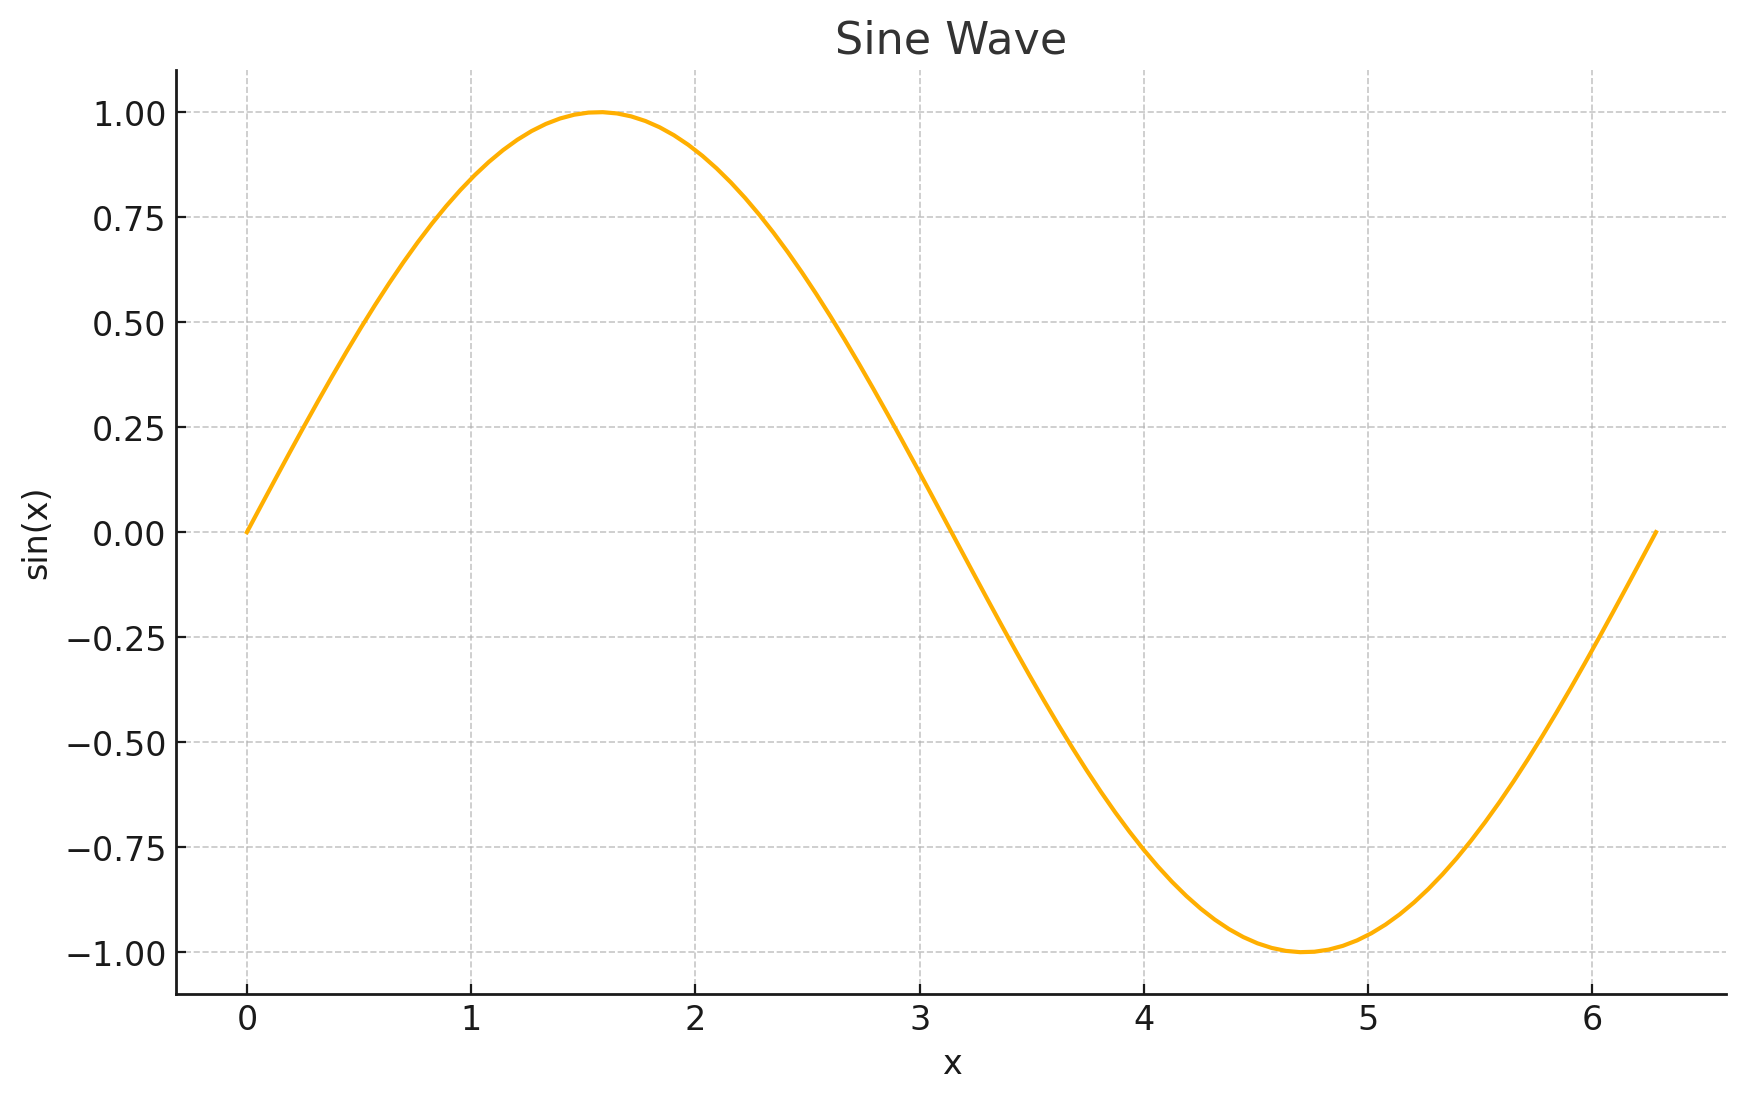

In [12]:
# rewrite the code to display the image in jupyter notebook

from PIL import Image

# Display the image in the default image viewer
image = Image.open("sinewave.png")
image.show()

## 후속 질문하기

In [13]:
# Add a new user question to the thread
message = client.beta.threads.messages.create(
    thread_id=thread.id,
    role="user",
    content="사인파를 생성하는 데 사용한 생성된 코드를 보여주세요."
)

In [14]:
run = client.beta.threads.runs.create(
  thread_id=thread.id,
  assistant_id=assistant.id,
  #instructions="New instructions" #You can optionally provide new instructions  but these will override the default instructions
)

# Retrieve the status of the run
run = client.beta.threads.runs.retrieve(
  thread_id=thread.id,
  run_id=run.id
)

status = run.status
print(status)

in_progress


In [15]:
messages = client.beta.threads.messages.list(
  thread_id=thread.id
)

print(messages.model_dump_json(indent=2))

{
  "data": [
    {
      "id": "msg_wRdmvThLVeCOo5SakjSGNv3T",
      "assistant_id": "asst_LwX3Bv0D0ysiVWbcMZa2Dpbl",
      "attachments": [],
      "completed_at": null,
      "content": [
        {
          "text": {
            "annotations": [],
            "value": "네, 사인파를 생성한 코드 부분은 아래와 같습니다.\n\n```python\nimport numpy as np\n\n# x축 데이터: 0부터 2π까지 100개의 점 생성\nx = np.linspace(0, 2 * np.pi, 100)\n\n# y축 데이터: 각 x값에 대해 사인값 계산\ny = np.sin(x)\n```\n\n이 코드에서  \n- `np.linspace(0, 2 * np.pi, 100)` : 0부터 \\(2\\pi\\)까지 100개의 균일한 값을 생성  \n- `np.sin(x)` : 각 x값에 대해 사인함수 값을 계산합니다.\n\n혹시 이 파형 데이터를 다른 방식으로 가공하거나 저장하고 싶으신가요?"
          },
          "type": "text"
        }
      ],
      "created_at": 1772442950,
      "incomplete_at": null,
      "incomplete_details": null,
      "metadata": {},
      "object": "thread.message",
      "role": "assistant",
      "run_id": "run_zNSTN5qujJOQZkKHhEvVjBGc",
      "status": null,
      "thread_id": "thread_5wbq3GVBMfOcipsqEEmNeIY0"
    },
    {
     

In [16]:
# Print the code
data = json.loads(messages.model_dump_json(indent=2))
code = data['data'][0]['content'][0]['text']['value']
print(code)

네, 사인파를 생성한 코드 부분은 아래와 같습니다.

```python
import numpy as np

# x축 데이터: 0부터 2π까지 100개의 점 생성
x = np.linspace(0, 2 * np.pi, 100)

# y축 데이터: 각 x값에 대해 사인값 계산
y = np.sin(x)
```

이 코드에서  
- `np.linspace(0, 2 * np.pi, 100)` : 0부터 \(2\pi\)까지 100개의 균일한 값을 생성  
- `np.sin(x)` : 각 x값에 대해 사인함수 값을 계산합니다.

혹시 이 파형 데이터를 다른 방식으로 가공하거나 저장하고 싶으신가요?
